# Clustering en Machine Learning: segmentacion de clientes

Este notebook desarrolla un analisis completo de **clustering no supervisado** usando Python y scikit-learn. El objetivo es agrupar clientes de un centro comercial en segmentos con caracteristicas similares.

A diferencia de clasificacion o regresion, aqui no existe una respuesta correcta conocida para entrenar el modelo. El trabajo consiste en descubrir estructura en los datos.

## 1. Introduccion al problema

Queremos descubrir grupos de clientes con comportamientos o perfiles similares. Por ejemplo, podrian aparecer segmentos como:

- Clientes con altos ingresos y alto gasto.
- Clientes con altos ingresos pero bajo gasto.
- Clientes jovenes con gasto elevado.
- Clientes con ingresos y gasto moderados.

Este es un problema de **aprendizaje no supervisado** porque no tenemos una variable objetivo `Y`. No existe una columna que diga a que segmento pertenece cada cliente. El algoritmo debe encontrar patrones usando solo las variables disponibles.

Dataset usado:

Usaremos el dataset **Mall Customers**, disponible publicamente en GitHub: https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv

El dataset contiene informacion basica de clientes: genero, edad, ingreso anual y puntaje de gasto. Es un caso clasico para explicar segmentacion de clientes con clustering.

## 2. Carga de librerias

Primero verificamos que las dependencias necesarias esten instaladas. Si alguna falta, la siguiente celda la instala con `pip`. Esto permite ejecutar el notebook desde cero en un entorno nuevo.

Usaremos:

- `pandas` y `numpy` para manipulacion de datos.
- `matplotlib` y `seaborn` para visualizacion.
- `scikit-learn` para escalado, clustering, PCA y metricas.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing_packages = [
    package_name
    for import_name, package_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Instalando dependencias faltantes:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Todas las dependencias necesarias estan instaladas.")

Todas las dependencias necesarias estan instaladas.


Importamos las librerias que se usaran durante todo el analisis. Tambien definimos una semilla aleatoria para obtener resultados reproducibles.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

## 3. Carga del dataset

Cargamos el archivo CSV directamente desde internet. Como es una fuente publica, no necesitamos archivos locales para ejecutar el notebook.

Luego mostramos las primeras filas para inspeccionar la estructura inicial.

In [3]:
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Revisamos la estructura general. En clustering no buscamos una variable objetivo; todas las variables seleccionadas seran usadas para medir similitud entre clientes.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


Columnas principales:

- `CustomerID`: identificador unico del cliente. No representa comportamiento, por lo que no debe usarse para clustering.
- `Gender`: genero del cliente, variable categorica.
- `Age`: edad del cliente.
- `Annual Income (k$)`: ingreso anual en miles de dolares.
- `Spending Score (1-100)`: puntaje asignado por el centro comercial segun comportamiento de gasto.

## 4. Analisis exploratorio de datos

Antes de aplicar clustering debemos entender los datos. Revisaremos dimensiones, tipos, valores nulos, estadisticas descriptivas y distribuciones. Esto ayuda a decidir que variables usar y como prepararlas.

In [5]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.dtypes

Filas: 200
Columnas: 5


CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Revisamos valores nulos. Si existieran, se podrian imputar o analizar segun su causa. En clustering, los valores nulos son problematicos porque los algoritmos necesitan calcular distancias entre observaciones.

In [6]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Calculamos estadisticas descriptivas de las variables numericas. Nos interesa conocer escalas, rangos y posibles valores extremos. La escala es especialmente importante porque K-Means y DBSCAN usan distancias.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


Observamos la distribucion de genero. Aunque el clustering no tiene variable objetivo, las variables categoricas pueden aportar informacion de perfil si se codifican correctamente.

Gender
Female    112
Male       88
Name: count, dtype: int64

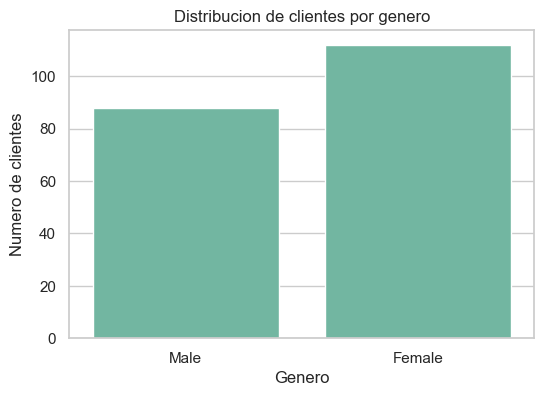

In [8]:
display(df["Gender"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender")
plt.title("Distribucion de clientes por genero")
plt.xlabel("Genero")
plt.ylabel("Numero de clientes")
plt.show()

Graficamos histogramas de edad, ingreso anual y puntaje de gasto. Estas distribuciones nos ayudan a ver si existen grupos naturales, dispersion o concentraciones.

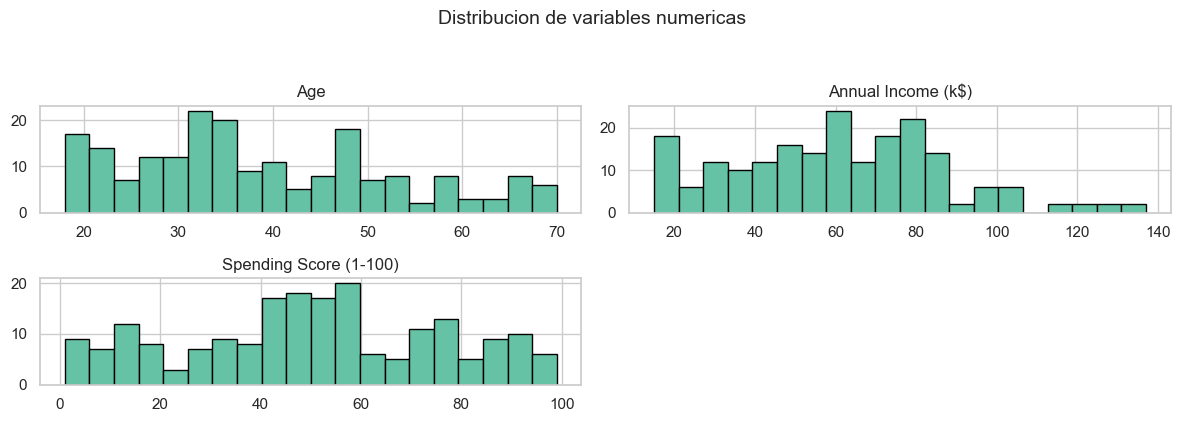

In [9]:
numeric_columns = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

df[numeric_columns].hist(figsize=(12, 4), bins=20, edgecolor="black")
plt.suptitle("Distribucion de variables numericas", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

Un grafico muy relevante en este dataset es ingreso anual contra puntaje de gasto. Esta relacion suele mostrar segmentos comerciales utiles: alto ingreso-alto gasto, alto ingreso-bajo gasto, bajo ingreso-alto gasto, etc.

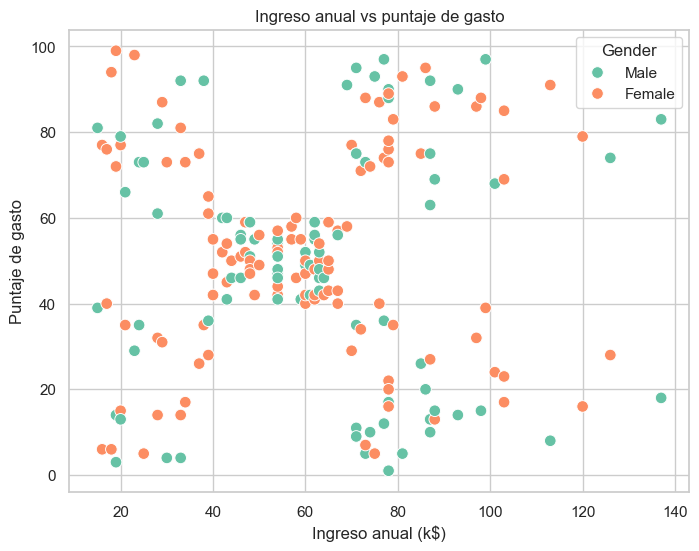

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=70,
)
plt.title("Ingreso anual vs puntaje de gasto")
plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Puntaje de gasto")
plt.show()

Revisamos correlaciones entre variables numericas. En clustering, la correlacion no determina los grupos, pero ayuda a entender relaciones entre variables antes de calcular distancias.

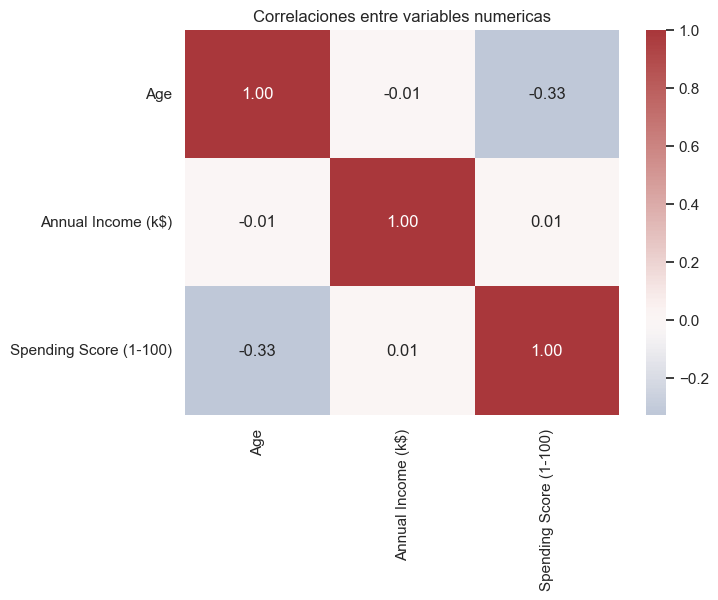

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlaciones entre variables numericas")
plt.show()

## 5. Preparacion de datos

Para clustering, la preparacion es critica porque los algoritmos comparan observaciones usando distancias.

Pasos:

- Eliminamos `CustomerID`, porque es solo un identificador.
- Codificamos `Gender` como variable numerica.
- Imputamos posibles valores nulos.
- Escalamos todas las variables numericas.

El escalado es obligatorio en este caso porque `Annual Income (k$)`, `Age` y `Spending Score (1-100)` tienen rangos diferentes. Sin escalado, una variable con valores mas grandes puede dominar las distancias y afectar artificialmente los clusters.

In [12]:
df_model = df.copy()

df_model["Gender_Encoded"] = df_model["Gender"].map({"Female": 0, "Male": 1})

features_for_clustering = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Gender_Encoded",
]

X = df_model[features_for_clustering]
X.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


Construimos un pipeline de preprocesamiento. La imputacion con mediana protege el flujo ante valores faltantes. `StandardScaler` transforma cada variable para que tenga media 0 y desviacion estandar 1.

In [13]:
preprocess_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_scaled = preprocess_pipeline.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


Verificamos como cambio la escala. Despues de `StandardScaler`, las medias deben estar cerca de 0 y las desviaciones estandar cerca de 1. Esto hace que las distancias sean mas equilibradas.

In [14]:
X_scaled_df.describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
Age,-0.0,1.003,-1.496,2.236
Annual Income (k$),-0.0,1.003,-1.739,2.918
Spending Score (1-100),-0.0,1.003,-1.910,1.894
Gender_Encoded,0.0,1.003,-0.886,1.128


## 6. Modelado: K-Means y DBSCAN

Entrenaremos dos algoritmos de clustering:

### K-Means

K-Means busca dividir los datos en `k` grupos. Cada grupo tiene un centroide, y cada observacion se asigna al centroide mas cercano. El algoritmo intenta minimizar la suma de distancias dentro de los clusters.

Hiperparametros principales:

- `n_clusters`: numero de clusters.
- `init`: metodo para inicializar centroides.
- `n_init`: numero de inicializaciones distintas.
- `max_iter`: iteraciones maximas.
- `random_state`: reproducibilidad.

### DBSCAN

DBSCAN agrupa puntos segun densidad. No necesita definir el numero de clusters de antemano y puede identificar ruido u outliers.

Hiperparametros principales:

- `eps`: radio maximo para considerar vecinos.
- `min_samples`: numero minimo de puntos para formar una region densa.
- `metric`: forma de medir distancia.

DBSCAN es sensible al escalado y a la eleccion de `eps`.

## 7. Seleccion de parametros para K-Means

Para elegir `k`, usaremos dos criterios:

- **Metodo del codo**: analiza la inercia, que mide que tan compactos son los clusters. Buscamos un punto donde la mejora empieza a disminuir.
- **Silhouette score**: mide que tan bien separado esta cada punto de otros clusters. Va aproximadamente de -1 a 1; valores mas altos indican clusters mas coherentes.

In [15]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

kmeans_selection = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouette_scores,
})

kmeans_selection

,k,inertia,silhouette
0,2,588.802677,0.251815
1,3,476.787554,0.259513
2,4,388.717861,0.298397
3,5,331.309884,0.304060
4,6,276.411760,0.331074
5,7,236.204947,0.357377
6,8,199.750461,0.387993
7,9,174.235477,0.403092
8,10,152.029834,0.420764


Graficamos el metodo del codo y el silhouette score. El codo sugiere un numero razonable de clusters segun compactacion; silhouette evalua separacion y cohesion.

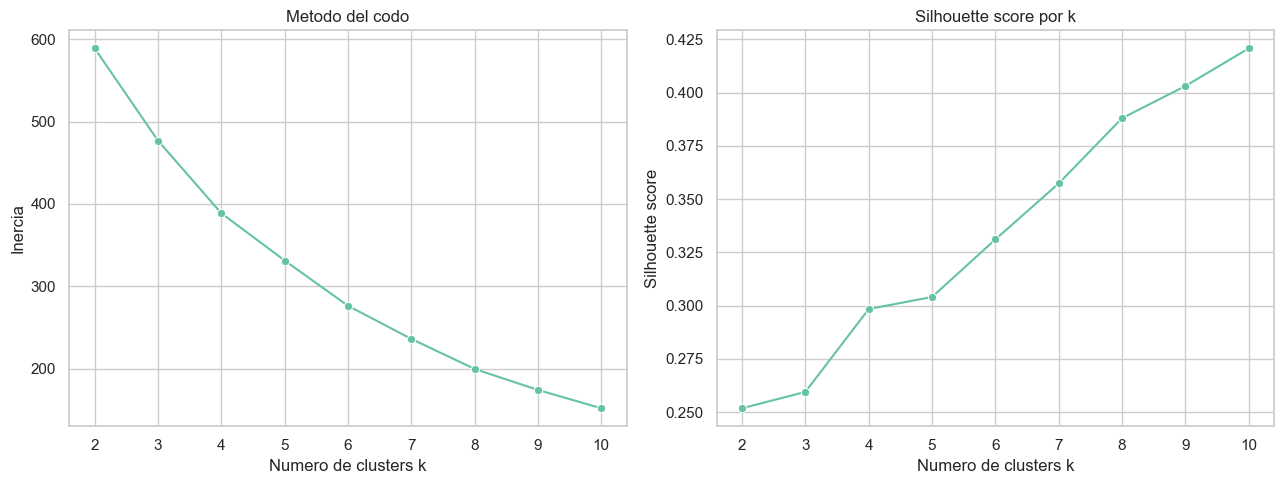

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(data=kmeans_selection, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Metodo del codo")
axes[0].set_xlabel("Numero de clusters k")
axes[0].set_ylabel("Inercia")

sns.lineplot(data=kmeans_selection, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette score por k")
axes[1].set_xlabel("Numero de clusters k")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

Seleccionaremos automaticamente el `k` con mejor silhouette score entre 2 y 10. En un proyecto real, esta decision tambien deberia considerar interpretabilidad del negocio.

In [17]:
best_k = int(kmeans_selection.loc[kmeans_selection["silhouette"].idxmax(), "k"])
best_k

10

## 8. Seleccion de parametros para DBSCAN

DBSCAN necesita elegir `eps` y `min_samples`.

- `eps`: distancia maxima para que dos puntos sean vecinos. Si es muy pequeno, muchos puntos quedan como ruido. Si es muy grande, clusters distintos pueden fusionarse.
- `min_samples`: cantidad minima de vecinos para formar un nucleo denso. Valores mas altos exigen clusters mas densos.

Probaremos varias combinaciones y calcularemos numero de clusters, cantidad de ruido y silhouette cuando sea posible.

In [18]:
eps_values = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
min_samples_values = [4, 5, 6, 8]
dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})
        n_noise = int(np.sum(labels == -1))
        noise_pct = n_noise / len(labels) * 100
        
        if n_clusters >= 2 and n_noise < len(labels) - 1:
            mask = labels != -1
            score = silhouette_score(X_scaled[mask], labels[mask]) if len(set(labels[mask])) >= 2 else np.nan
        else:
            score = np.nan
        
        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_pct": noise_pct,
            "silhouette_without_noise": score,
        })

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df.sort_values(["silhouette_without_noise", "n_clusters"], ascending=[False, False]).head(10)

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette_without_noise
2,0.4,6,2,177,88.5,0.746455
1,0.4,5,4,165,82.5,0.711616
7,0.5,8,2,169,84.5,0.708924
0,0.4,4,8,133,66.5,0.637168
6,0.5,6,5,135,67.5,0.629881
11,0.6,8,7,111,55.5,0.568370
4,0.5,4,12,76,38.0,0.556928
5,0.5,5,9,105,52.5,0.539519
10,0.6,6,7,83,41.5,0.482975
15,0.7,8,5,76,38.0,0.394808


Para elegir una configuracion de DBSCAN, buscamos un equilibrio: al menos dos clusters, un porcentaje de ruido razonable y un silhouette aceptable. Evitamos configuraciones donde casi todo queda como ruido o donde solo aparece un cluster.

In [19]:
valid_dbscan = dbscan_results_df[
    (dbscan_results_df["n_clusters"] >= 2)
    & (dbscan_results_df["noise_pct"] <= 35)
    & (dbscan_results_df["silhouette_without_noise"].notna())
].copy()

if valid_dbscan.empty:
    selected_eps = 0.8
    selected_min_samples = 5
else:
    selected_row = valid_dbscan.sort_values("silhouette_without_noise", ascending=False).iloc[0]
    selected_eps = float(selected_row["eps"])
    selected_min_samples = int(selected_row["min_samples"])

print(f"eps seleccionado: {selected_eps}")
print(f"min_samples seleccionado: {selected_min_samples}")

eps seleccionado: 0.7
min_samples seleccionado: 6


## 9. Entrenamiento de los modelos

Entrenamos K-Means con el `k` seleccionado y DBSCAN con la configuracion seleccionada. Luego guardamos las etiquetas de cluster en una copia del dataset original para poder interpretar los grupos.

In [20]:
kmeans_final = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

dbscan_final = DBSCAN(eps=selected_eps, min_samples=selected_min_samples)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

df_clusters = df_model.copy()
df_clusters["cluster_kmeans"] = kmeans_labels
df_clusters["cluster_dbscan"] = dbscan_labels

df_clusters.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,cluster_kmeans,cluster_dbscan
0,1,Male,19,15,39,1,1,-1
1,2,Male,21,15,81,1,1,1
2,3,Female,20,16,6,0,2,-1
3,4,Female,23,16,77,0,8,0
4,5,Female,31,17,40,0,2,-1


## 10. Evaluacion del clustering

En clustering no tenemos accuracy porque no hay etiquetas reales. Usaremos:

- **Silhouette score**: cohesion y separacion de clusters.
- **Tamanos de clusters**: grupos demasiado pequenos o demasiado grandes pueden ser menos utiles.
- **Visualizacion 2D con PCA**: reduce las variables a dos componentes para graficar los clusters.
- **Ruido en DBSCAN**: etiqueta `-1`, que representa puntos considerados outliers.

In [21]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

dbscan_mask = dbscan_labels != -1
dbscan_n_clusters = len(set(dbscan_labels) - {-1})

if dbscan_n_clusters >= 2 and dbscan_mask.sum() > 1:
    dbscan_silhouette = silhouette_score(X_scaled[dbscan_mask], dbscan_labels[dbscan_mask])
else:
    dbscan_silhouette = np.nan

evaluation = pd.DataFrame({
    "modelo": ["K-Means", "DBSCAN"],
    "n_clusters": [best_k, dbscan_n_clusters],
    "silhouette": [kmeans_silhouette, dbscan_silhouette],
    "n_noise": [0, int(np.sum(dbscan_labels == -1))],
})

evaluation

,modelo,n_clusters,silhouette,n_noise
0,K-Means,10,0.420764,0
1,DBSCAN,8,0.362122,47


Analizamos el tamano de los clusters. En K-Means todos los clientes pertenecen a un cluster. En DBSCAN, la etiqueta `-1` indica ruido u observaciones que no pertenecen claramente a una region densa.

In [22]:
print("Tamanos de clusters K-Means:")
display(df_clusters["cluster_kmeans"].value_counts().sort_index())

print("Tamanos de clusters DBSCAN (-1 = ruido):")
display(df_clusters["cluster_dbscan"].value_counts().sort_index())

Tamanos de clusters K-Means:


cluster_kmeans
0    26
1    24
2    14
3    21
4    26
5    19
6    25
7    18
8    13
9    14
Name: count, dtype: int64

Tamanos de clusters DBSCAN (-1 = ruido):


cluster_dbscan
-1    47
 0    69
 1     6
 2    23
 3    10
 4    11
 5    21
 6     4
 7     9
Name: count, dtype: int64

Usamos PCA para representar los datos escalados en dos dimensiones. Esta visualizacion no es el modelo completo, sino una proyeccion que ayuda a observar separacion aproximada entre clusters.

In [23]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster_kmeans"] = kmeans_labels.astype(str)
pca_df["cluster_dbscan"] = dbscan_labels.astype(str)

print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_.round(3))

Varianza explicada por PC1 y PC2: [0.337 0.262]


Visualizamos los clusters generados por K-Means y DBSCAN en el espacio PCA. En DBSCAN, el cluster `-1` corresponde a ruido.

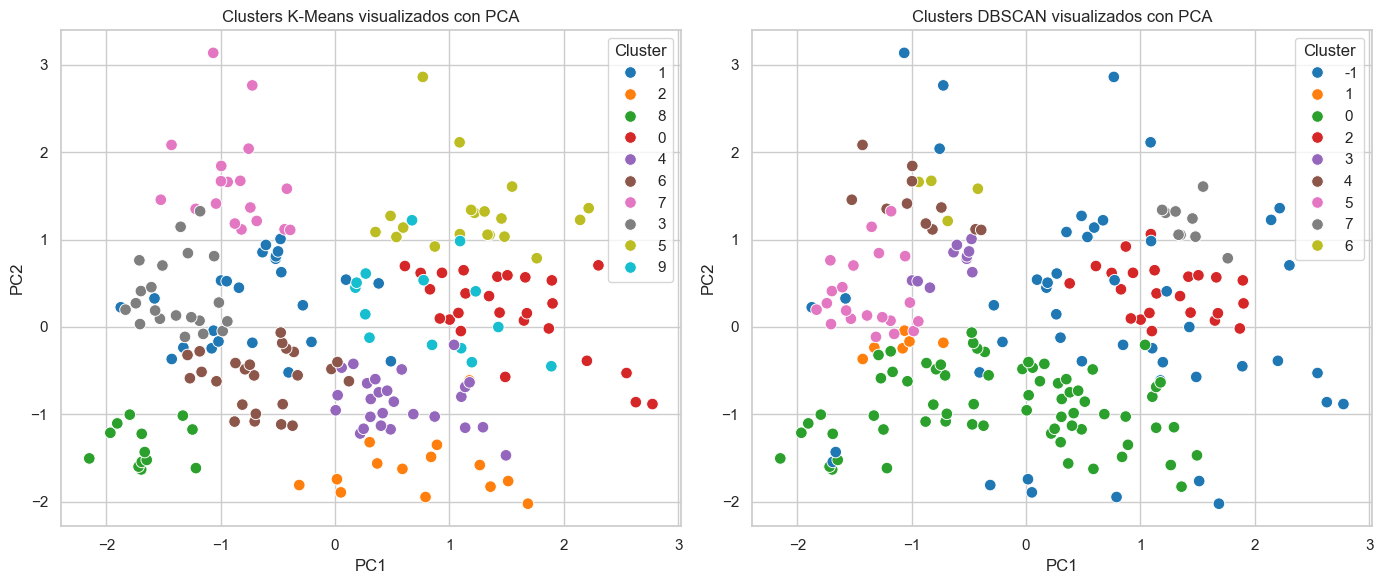

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster_kmeans", palette="tab10", s=70, ax=axes[0])
axes[0].set_title("Clusters K-Means visualizados con PCA")
axes[0].legend(title="Cluster")

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster_dbscan", palette="tab10", s=70, ax=axes[1])
axes[1].set_title("Clusters DBSCAN visualizados con PCA")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

Tambien visualizamos los clusters sobre las dos variables de negocio mas intuitivas: ingreso anual y puntaje de gasto. Esta grafica suele ser la mas clara para interpretar segmentacion comercial.

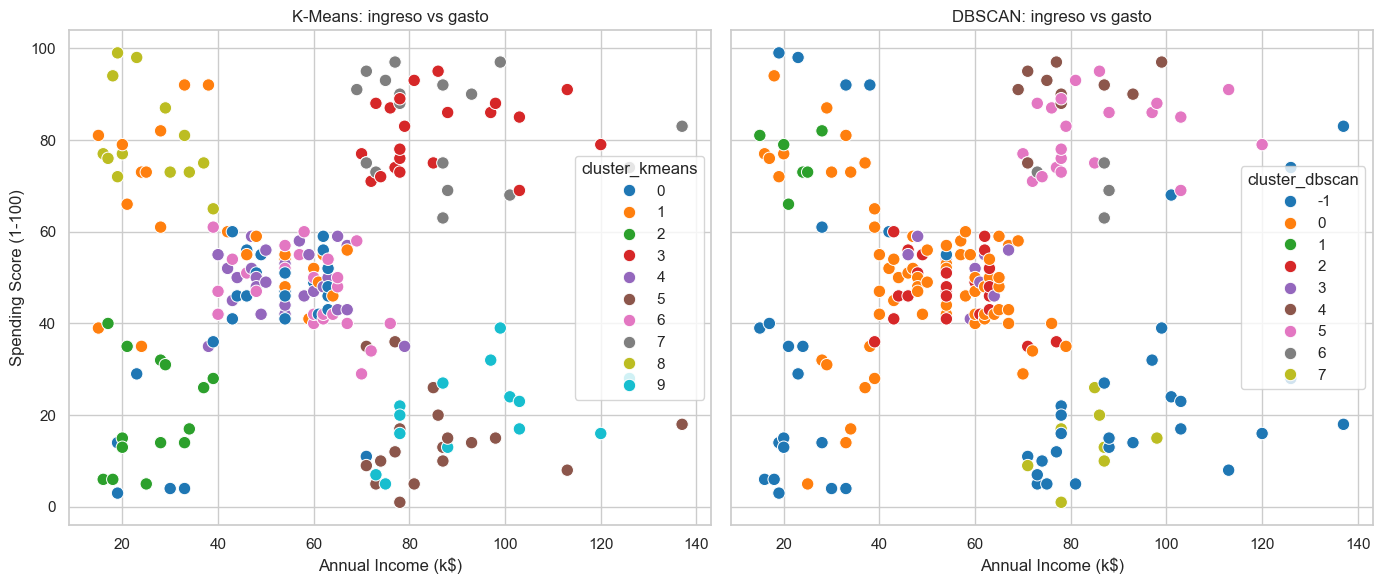

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=df_clusters,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="cluster_kmeans",
    palette="tab10",
    s=80,
    ax=axes[0],
)
axes[0].set_title("K-Means: ingreso vs gasto")

sns.scatterplot(
    data=df_clusters,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="cluster_dbscan",
    palette="tab10",
    s=80,
    ax=axes[1],
)
axes[1].set_title("DBSCAN: ingreso vs gasto")

plt.tight_layout()
plt.show()

## 11. Interpretacion de clusters

Para interpretar los clusters calculamos promedios por grupo. Esto convierte etiquetas abstractas como `cluster 0` o `cluster 1` en perfiles comprensibles de clientes.

In [26]:
profile_columns = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender_Encoded"]

kmeans_profile = df_clusters.groupby("cluster_kmeans")[profile_columns].mean().round(2)
kmeans_profile["n_clientes"] = df_clusters["cluster_kmeans"].value_counts().sort_index()

kmeans_profile

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,n_clientes
cluster_kmeans,,,,,
0,58.85,48.69,39.85,1.00,26
1,25.25,41.25,60.92,1.00,24
2,41.21,26.07,20.14,0.07,14
3,32.19,86.05,81.67,0.00,21
4,54.15,54.23,48.96,0.00,26
5,38.47,85.89,14.21,1.00,19
6,27.96,57.36,47.12,0.00,25
7,33.28,87.11,82.67,1.00,18
8,25.46,25.69,80.54,0.00,13


Creamos una descripcion automatica para cada cluster de K-Means. La idea es traducir los promedios a etiquetas de negocio como ingreso alto, gasto bajo o clientes jovenes.

In [27]:
income_median = df_clusters["Annual Income (k$)"].median()
spending_median = df_clusters["Spending Score (1-100)"].median()
age_median = df_clusters["Age"].median()

def describe_cluster(row):
    income_level = "ingreso alto" if row["Annual Income (k$)"] >= income_median else "ingreso bajo/medio"
    spending_level = "gasto alto" if row["Spending Score (1-100)"] >= spending_median else "gasto bajo/medio"
    age_level = "clientes mas jovenes" if row["Age"] < age_median else "clientes de mayor edad relativa"
    return f"{income_level}, {spending_level}, {age_level}"

kmeans_profile["interpretacion"] = kmeans_profile.apply(describe_cluster, axis=1)
kmeans_profile

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,n_clientes,interpretacion
cluster_kmeans,,,,,,
0,58.85,48.69,39.85,1.00,26,"ingreso bajo/medio, gasto bajo/medio, clientes..."
1,25.25,41.25,60.92,1.00,24,"ingreso bajo/medio, gasto alto, clientes mas j..."
2,41.21,26.07,20.14,0.07,14,"ingreso bajo/medio, gasto bajo/medio, clientes..."
3,32.19,86.05,81.67,0.00,21,"ingreso alto, gasto alto, clientes mas jovenes"
4,54.15,54.23,48.96,0.00,26,"ingreso bajo/medio, gasto bajo/medio, clientes..."
5,38.47,85.89,14.21,1.00,19,"ingreso alto, gasto bajo/medio, clientes de ma..."
6,27.96,57.36,47.12,0.00,25,"ingreso bajo/medio, gasto bajo/medio, clientes..."
7,33.28,87.11,82.67,1.00,18,"ingreso alto, gasto alto, clientes mas jovenes"
8,25.46,25.69,80.54,0.00,13,"ingreso bajo/medio, gasto alto, clientes mas j..."


Perfilamos DBSCAN. Recordemos que `-1` significa ruido: clientes que el algoritmo no pudo asignar a una region densa clara.

In [28]:
dbscan_profile = df_clusters.groupby("cluster_dbscan")[profile_columns].mean().round(2)
dbscan_profile["n_clientes"] = df_clusters["cluster_dbscan"].value_counts().sort_index()

dbscan_profile

,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,n_clientes
cluster_dbscan,,,,,
-1,39.68,64.19,30.34,0.53,47
0,38.77,48.71,50.06,0.00,69
1,24.67,22.17,75.67,1.00,6
2,56.78,55.35,47.39,1.00,23
3,21.60,56.90,52.60,1.00,10
4,35.45,79.00,89.36,1.00,11
5,32.19,86.05,81.67,0.00,21
6,29.75,83.75,70.00,1.00,4
7,41.67,83.11,12.44,1.00,9


Comparamos los resultados. K-Means fuerza a todos los clientes a pertenecer a algun grupo y suele ser facil de interpretar en segmentacion comercial. DBSCAN puede encontrar grupos densos y separar ruido, pero en datasets pequenos o con densidades similares puede producir pocos clusters o marcar demasiados puntos como outliers.

In [29]:
print("Resumen comparativo")
display(evaluation)

if pd.isna(dbscan_silhouette):
    print("DBSCAN no produjo suficientes clusters validos para calcular silhouette de forma confiable.")
elif kmeans_silhouette >= dbscan_silhouette:
    print("K-Means obtiene mayor o igual silhouette en esta configuracion y ofrece segmentos mas directos para negocio.")
else:
    print("DBSCAN obtiene mayor silhouette sin contar ruido, pero debe revisarse si el porcentaje de outliers es aceptable para el negocio.")

Resumen comparativo


,modelo,n_clusters,silhouette,n_noise
0,K-Means,10,0.420764,0
1,DBSCAN,8,0.362122,47


K-Means obtiene mayor o igual silhouette en esta configuracion y ofrece segmentos mas directos para negocio.


## 12. Conclusiones

En este notebook realizamos un analisis completo de clustering no supervisado para segmentacion de clientes.

Patrones encontrados:

- El ingreso anual y el puntaje de gasto permiten distinguir perfiles comerciales utiles.
- Es posible encontrar clientes con alto ingreso y alto gasto, que podrian ser prioritarios para estrategias premium.
- Tambien aparecen clientes con alto ingreso pero bajo gasto, que podrian requerir estrategias de activacion o fidelizacion.
- Algunos clientes se comportan como observaciones menos densas o atipicas segun DBSCAN.

Comparacion de algoritmos:

- **K-Means** suele ser mas facil de comunicar en negocio porque produce un numero fijo de segmentos y asigna todos los clientes.
- **DBSCAN** es util para detectar ruido/outliers y clusters basados en densidad, pero depende mucho de `eps` y `min_samples`.
- El mejor algoritmo depende del objetivo: segmentacion comercial clara favorece K-Means; deteccion de grupos densos y anomalias puede favorecer DBSCAN.

Limitaciones:

- El dataset es pequeno y didactico.
- El puntaje de gasto ya es una variable construida por el negocio; no conocemos exactamente como se calculo.
- No hay validacion externa de los segmentos.
- PCA ayuda a visualizar, pero puede perder informacion al reducir dimensiones.

Posibles mejoras:

- Incluir variables reales de frecuencia de compra, valor monetario, categorias compradas y recencia.
- Probar clustering jerarquico o Gaussian Mixture Models.
- Usar analisis RFM si se tienen transacciones.
- Validar los segmentos con expertos de negocio.
- Evaluar estabilidad de clusters con diferentes muestras o periodos de tiempo.